## Bias vs Variance + 常見模型對應整理

### 一、Bias vs Variance 核心概念

| 面向 | Bias（偏差） | Variance（變異） |
|------|-------------|----------------|
| 核心問題 | 模型是否偏離真實答案 | 模型是否對資料過度敏感 |
| 白話理解 | 平均預測 vs 真實值的差距 | 每次訓練結果是否大幅變動 |
| 本質 | 模型假設過於簡單 | 模型過度貼近資料細節 |
| 對訓練資料 | 表現差 | 表現很好 |
| 對測試資料 | 表現差 | 表現差 |
| 對應問題 | Underfitting | Overfitting |
| 決策邊界 | 過於平滑 | 過於鋸齒 |
| 對雜訊反應 | 不敏感 | 非常敏感 |

---

### 二、Bias-Variance Tradeoff

| 模型複雜度 | Bias | Variance | 結果 |
|-----------|------|----------|------|
| 低（簡單模型） | 高 | 低 | Underfitting |
| 中（適中） | 適中 | 適中 | 最佳泛化能力 |
| 高（複雜模型） | 低 | 高 | Overfitting |

---

### 三、不同模型的 Bias / Variance 特性

| 模型 | Bias | Variance | 說明 |
|------|------|----------|------|
| Linear Regression | 高 | 低 | 假設線性關係，無法擬合複雜資料 |
| Logistic Regression | 高 | 低 | 決策邊界為線性 |
| KNN（K 很大） | 高 | 低 | 過度平均，忽略局部特徵 |
| KNN（K 很小） | 低 | 高 | 對單一樣本敏感，容易 overfit |
| Decision Tree（淺） | 高 | 低 | 分裂少，模型簡單 |
| Decision Tree（深） | 低 | 高 | 容易記住訓練資料（overfit） |
| Random Forest | 中 | 中偏低 | 平衡 variance（bagging 降低 overfit） |
| Gradient Boosting | 低 | 中偏高 | 容易 overfit（需調參） |

---

### 四、如何調整 Bias / Variance

| 方法 | 影響 |
|------|------|
| 增加模型複雜度 | ↓ Bias，↑ Variance |
| 降低模型複雜度 | ↑ Bias，↓ Variance |
| 增加資料量 | ↓ Variance |
| 正則化（Regularization） | ↑ Bias，↓ Variance |
| Ensemble（如 Random Forest） | ↓ Variance |

---

### 五、KNN / Decision Tree 對應理解（面試高頻）

| 模型 | 參數 | 效果 |
|------|------|------|
| KNN | K 小 | 高 Variance（overfit） |
| KNN | K 大 | 高 Bias（underfit） |
| Decision Tree | max_depth 大 | 高 Variance |
| Decision Tree | max_depth 小 | 高 Bias |

---

### 六、一句話面試版（超重要🔥）

- Bias：模型平均預測偏離真實值的程度（模型太簡單 → underfit）
- Variance：模型對訓練資料變動的敏感度（模型太複雜 → overfit）

👉 Overfitting = High Variance  
👉 Underfitting = High Bias  

---

### 七、核心公式（記憶用）

E[(y - f̂(x))²] = Bias² + Variance + Noise

## Bias / Variance 與模型參數變化觀察

下面用兩個常見模型做示範：

1. **KNN**
   - `k` 小：模型更貼近訓練資料，容易 overfitting（high variance）
   - `k` 大：模型更平滑，容易 underfitting（high bias）

2. **Decision Tree**
   - `max_depth` 大：模型更複雜，容易 overfitting（high variance）
   - `max_depth` 小：模型更簡單，容易 underfitting（high bias）

---

## 1. 載入套件

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## 2. 準備資料

這裡使用 iris 資料集，並只取前兩個特徵，方便後續視覺化。

In [4]:
iris = load_iris()
X = iris.data[:, :2]   # 只取前兩個特徵方便畫圖
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## 3. 觀察 KNN：k 值對 bias / variance 的影響

In [5]:
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

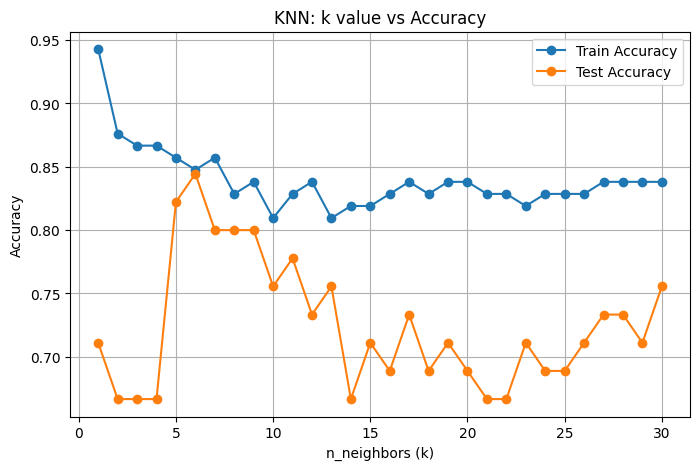

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_scores, marker='o', label='Train Accuracy')
plt.plot(k_values, test_scores, marker='o', label='Test Accuracy')
plt.xlabel("n_neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN: k value vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### KNN 圖表解讀

- 當 `k=1` 時，模型幾乎記住訓練資料  
  - train accuracy 常常非常高
  - test accuracy 可能沒有同樣高
  - 代表模型對資料細節與雜訊過度敏感  
  - **→ high variance / overfitting**

- 當 `k` 越來越大時，模型會越來越平滑  
  - train accuracy 下降
  - test accuracy 先上升後可能再下降
  - 如果 `k` 太大，模型只剩下大方向判斷  
  - **→ high bias / underfitting**

- 通常 test accuracy 最高附近的 `k`，可視為較平衡的位置

## 4. 觀察 Decision Tree：max_depth 對 bias / variance 的影響

In [7]:
depth_values = range(1, 11)
train_scores_tree = []
test_scores_tree = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_scores_tree.append(accuracy_score(y_train, y_train_pred))
    test_scores_tree.append(accuracy_score(y_test, y_test_pred))

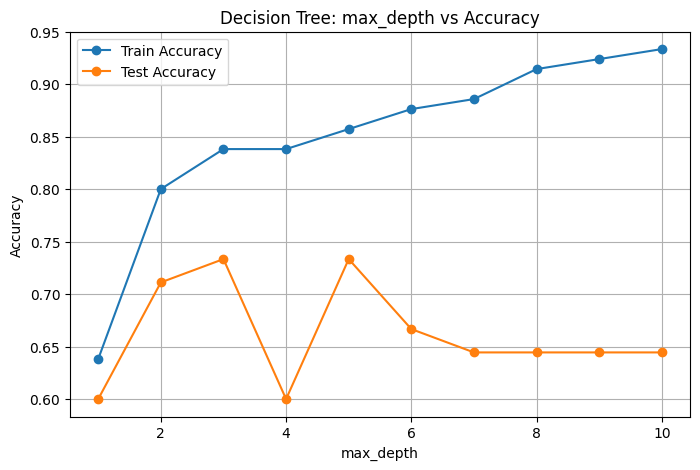

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(depth_values, train_scores_tree, marker='o', label='Train Accuracy')
plt.plot(depth_values, test_scores_tree, marker='o', label='Test Accuracy')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: max_depth vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Decision Tree 圖表解讀

- 當 `max_depth` 很小時  
  - 樹很淺
  - 規則很簡單
  - train 與 test 表現都可能不夠好  
  - **→ high bias / underfitting**

- 當 `max_depth` 逐漸增加時  
  - 模型可以學到更多資料細節
  - train accuracy 往往持續上升

- 當 `max_depth` 太大時  
  - 模型容易把訓練資料記得太細
  - train accuracy 很高，test accuracy 不一定跟著提高
  - 甚至 test accuracy 下降  
  - **→ high variance / overfitting**

## 5. 重點整理表

| 模型 | 參數變小 / 變低 | 結果 | 參數變大 / 變高 | 結果 |
|------|------------------|------|------------------|------|
| KNN | k 小 | 高 variance，容易 overfit | k 大 | 高 bias，容易 underfit |
| Decision Tree | max_depth 小 | 高 bias，容易 underfit | max_depth 大 | 高 variance，容易 overfit |

### 觀察結論

從 KNN 的結果可看出，當 k 很小時，模型在訓練集上的表現非常高，但測試集未必同步提升，表示模型可能過度貼近訓練資料，呈現 high variance / overfitting 的現象。隨著 k 增加，模型逐漸平滑，若 k 過大則可能因過度平均而產生 high bias / underfitting。

從 Decision Tree 的結果可看出，較小的 max_depth 會使模型過於簡單，無法充分擬合資料；但當 max_depth 過大時，模型則容易記住訓練資料細節，使訓練表現過高而泛化能力下降。

## 6. 一句話總結

- **Bias**：模型太簡單，抓不到資料規律  
- **Variance**：模型太複雜，太容易受訓練資料波動影響  

在實際建模時，我們通常不是追求 train accuracy 最高，而是要找 **test / validation 表現最穩定** 的那個平衡點。

## Bias / Variance 視覺化：觀察決策邊界變化

這裡透過 **KNN** 和 **Decision Tree** 的決策邊界圖，觀察模型複雜度如何影響：

- **Bias**
- **Variance**
- **Overfitting / Underfitting**

---

### 觀察重點

#### KNN
- `k` 小：只看很少鄰居，決策邊界容易很鋸齒，對局部資料過度敏感
- `k` 大：會把邊界變得更平滑，但也可能過度平均

#### Decision Tree
- `max_depth` 小：規則很少，邊界簡單
- `max_depth` 大：規則很多，邊界容易切得很碎，甚至像在「背答案」

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

## 1. 準備資料

這裡使用 iris 資料集，並只取前兩個特徵，方便畫 2D 決策邊界。

In [10]:
iris = load_iris()
X = iris.data[:, :2]   # 只取前兩個特徵方便視覺化
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## 2. 畫決策邊界的函式

這個函式的用途是：

1. 建立整個平面的網格點
2. 讓模型對每個格點做預測
3. 把預測結果畫成背景顏色
4. 再把原始資料點畫上去

In [11]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02  # 網格步長，越小圖越細

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(title)
    plt.show()

## 3. KNN：比較不同 k 值的決策邊界

In [12]:
knn_k1 = KNeighborsClassifier(n_neighbors=1)
knn_k1.fit(X_train, y_train)

knn_k5 = KNeighborsClassifier(n_neighbors=5)
knn_k5.fit(X_train, y_train)

knn_k20 = KNeighborsClassifier(n_neighbors=20)
knn_k20.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


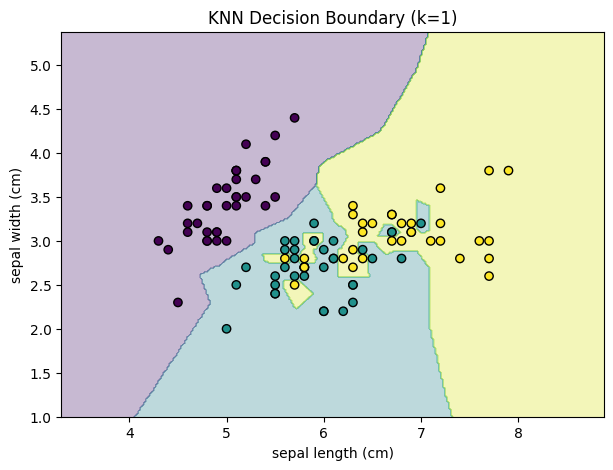

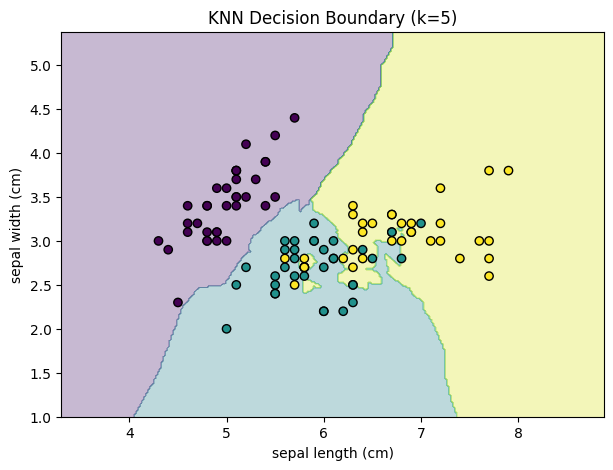

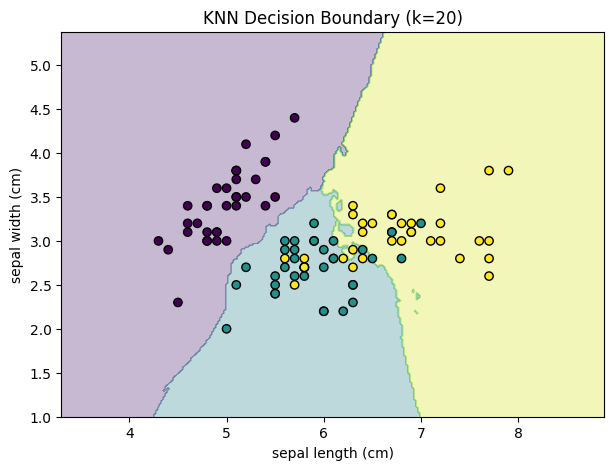

In [13]:
plot_decision_boundary(knn_k1, X_train, y_train, "KNN Decision Boundary (k=1)")
plot_decision_boundary(knn_k5, X_train, y_train, "KNN Decision Boundary (k=5)")
plot_decision_boundary(knn_k20, X_train, y_train, "KNN Decision Boundary (k=20)")

### KNN 圖形解讀

#### 當 k = 1
- 模型只看最近的 1 個點
- 很容易被局部資料影響
- 決策邊界通常很碎、很鋸齒
- 容易出現 **high variance / overfitting**

#### 當 k = 5
- 會比 k=1 更平滑
- 通常是比較合理的折衷位置

#### 當 k = 20
- 模型會看很大範圍的鄰居
- 邊界變得更平滑
- 若太平滑，可能忽略局部特徵
- 容易出現 **high bias / underfitting**

## 4. Decision Tree：比較不同 max_depth 的決策邊界

In [15]:
tree_d1 = DecisionTreeClassifier(max_depth=1, random_state=42)
tree_d1.fit(X_train, y_train)

tree_d3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_d3.fit(X_train, y_train)

tree_dNone = DecisionTreeClassifier(random_state=42)
tree_dNone.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

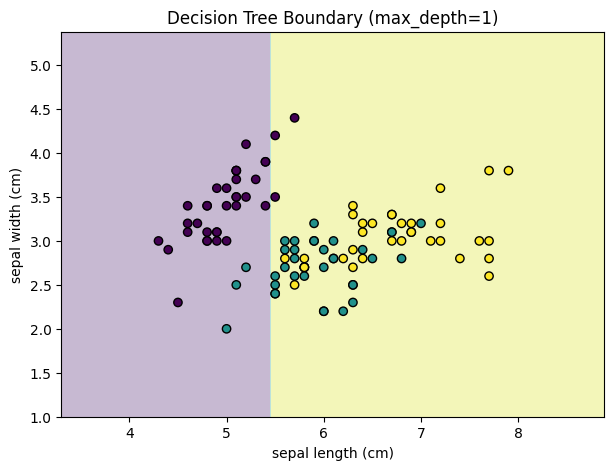

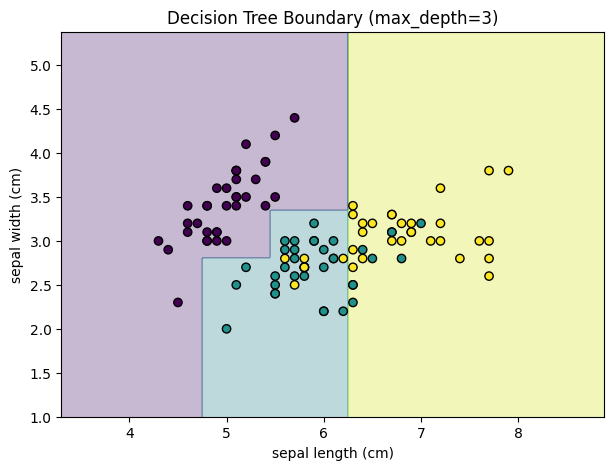

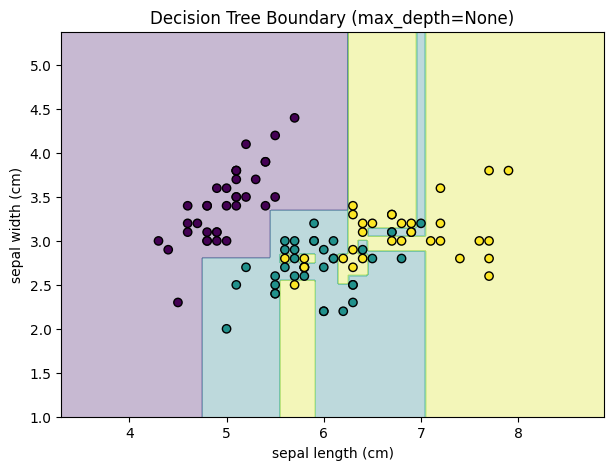

In [16]:
plot_decision_boundary(tree_d1, X_train, y_train, "Decision Tree Boundary (max_depth=1)")
plot_decision_boundary(tree_d3, X_train, y_train, "Decision Tree Boundary (max_depth=3)")
plot_decision_boundary(tree_dNone, X_train, y_train, "Decision Tree Boundary (max_depth=None)")

### Decision Tree 圖形解讀

#### 當 max_depth = 1
- 樹只能做很少次切分
- 規則非常簡單
- 邊界通常很粗略
- 容易 **underfitting / high bias**

#### 當 max_depth = 3
- 可以學到更多資料規律
- 邊界通常比 depth=1 更合理

#### 當 max_depth = None
- 樹會持續切分，直到接近把訓練資料分乾淨
- 邊界可能變得非常碎
- 很容易記住訓練資料細節
- 容易 **overfitting / high variance**

## 5. 重點整理表

| 模型 | 參數 | 邊界特徵 | 傾向 |
|------|------|----------|------|
| KNN | k 小 | 鋸齒、碎裂、貼近局部資料 | High Variance / Overfitting |
| KNN | k 大 | 平滑、較大範圍平均 | High Bias / Underfitting |
| Decision Tree | max_depth 小 | 切分少、邊界簡單 | High Bias / Underfitting |
| Decision Tree | max_depth 大 | 切分多、邊界複雜 | High Variance / Overfitting |

### 觀察結論

從 KNN 的決策邊界圖可看出，當 k 很小時，模型的分類區域會隨著局部樣本分布出現明顯波動，表示模型對訓練資料十分敏感，容易形成 high variance 與 overfitting。隨著 k 增加，決策邊界逐漸平滑，模型會更偏向整體趨勢；但若 k 過大，也可能因過度平均而導致 underfitting。

從 Decision Tree 的圖可看出，較小的 max_depth 只能形成簡單規則，因此可能無法充分擬合資料；但隨著 max_depth 增加，模型可建立更細的切分規則，若深度過大，則容易把訓練資料切得過碎，導致 high variance 與 overfitting。

## 6. 一句話總結

- **KNN 的複雜度主要來自 k 值**
  - k 越小，模型越容易貼近訓練資料
  - k 越大，模型越容易過度平均

- **Decision Tree 的複雜度主要來自樹的深度**
  - 深度越小，模型越簡單
  - 深度越大，模型越容易記住資料細節

因此，訓練模型時的目標不是讓邊界越複雜越好，而是找到一個能兼顧訓練表現與泛化能力的平衡點。

## Bias / Variance 視覺化進階版：決策邊界 + Train/Test Accuracy

這裡同時觀察：

1. **模型決策邊界**
2. **Train Accuracy**
3. **Test Accuracy**

這樣可以更完整理解：

- 模型是否過度貼近訓練資料
- 模型是否具有泛化能力
- 為什麼 high variance 常伴隨 overfitting
- 為什麼 high bias 常伴隨 underfitting

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## 1. 準備資料

這裡使用 iris 資料集，並只取前兩個特徵做 2D 視覺化。

In [19]:
iris = load_iris()
X = iris.data[:, :2]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## 2. 建立畫決策邊界的函式

In [20]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(title)
    plt.show()

## 3. 建立評估函式

這個函式會回傳：

- train accuracy
- test accuracy
- gap（train - test）

其中 gap 可幫助我們初步判斷是否有 overfitting 傾向。

In [21]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    gap = train_acc - test_acc

    return train_acc, test_acc, gap

## 4. KNN：比較不同 k 值

KNN (k=1)
Train Accuracy: 0.943
Test Accuracy : 0.711
Gap           : 0.232
------------------------------


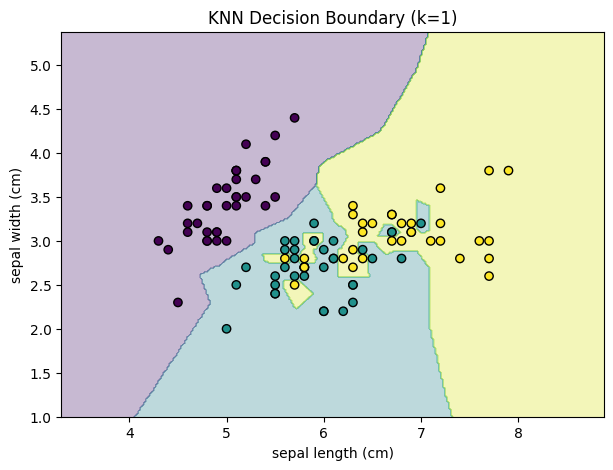

KNN (k=5)
Train Accuracy: 0.857
Test Accuracy : 0.822
Gap           : 0.035
------------------------------


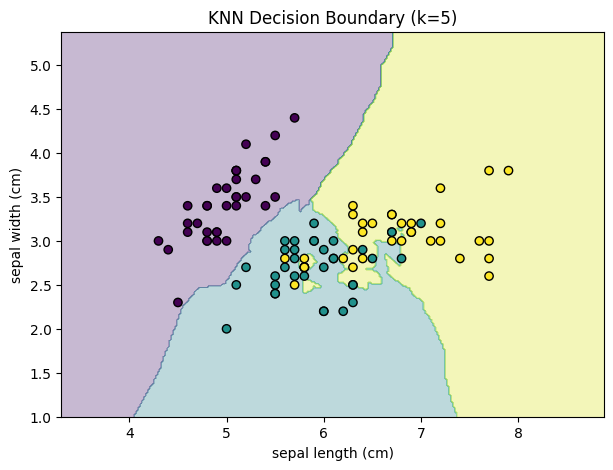

KNN (k=20)
Train Accuracy: 0.838
Test Accuracy : 0.689
Gap           : 0.149
------------------------------


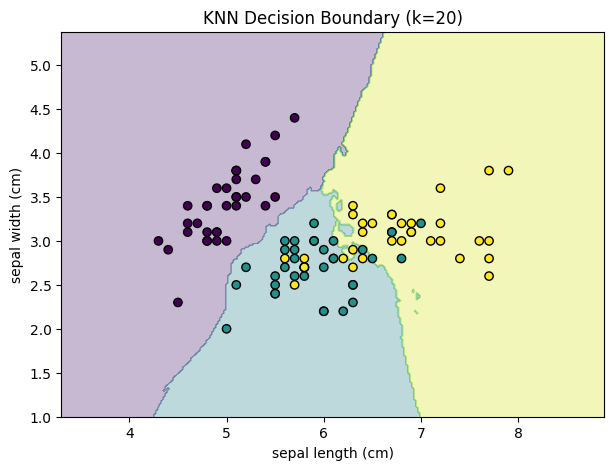

In [22]:
k_list = [1, 5, 20]

for k in k_list:
    model = KNeighborsClassifier(n_neighbors=k)
    train_acc, test_acc, gap = evaluate_model(model, X_train, X_test, y_train, y_test)

    print(f"KNN (k={k})")
    print(f"Train Accuracy: {train_acc:.3f}")
    print(f"Test Accuracy : {test_acc:.3f}")
    print(f"Gap           : {gap:.3f}")
    print("-" * 30)

    plot_decision_boundary(model, X_train, y_train, f"KNN Decision Boundary (k={k})")

### KNN 結果解讀

#### 當 k 很小（例如 k=1）
- 決策邊界通常很鋸齒、很碎
- train accuracy 往往很高
- 若 test accuracy 沒有同步提高，表示模型太貼近訓練資料
- 這通常代表 **high variance / overfitting**

#### 當 k 適中（例如 k=5）
- 決策邊界比較平滑
- train/test accuracy 往往更平衡
- 可能是較好的泛化位置

#### 當 k 很大（例如 k=20）
- 決策邊界會變得更平滑
- 若 train/test accuracy 都不高，表示模型可能過度簡化
- 這通常代表 **high bias / underfitting**

## 5. Decision Tree：比較不同 max_depth

Decision Tree (max_depth=1)
Train Accuracy: 0.638
Test Accuracy : 0.600
Gap           : 0.038
------------------------------


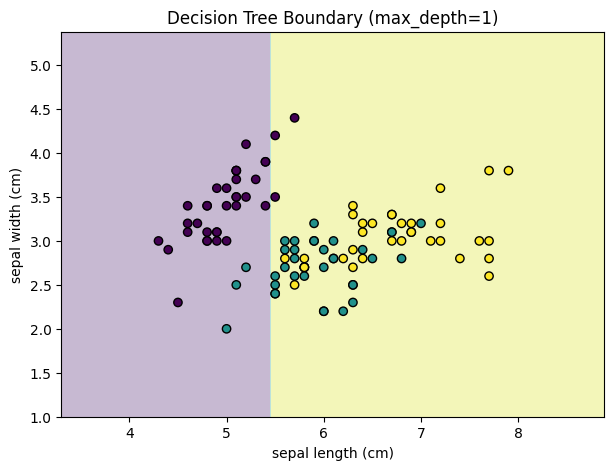

Decision Tree (max_depth=3)
Train Accuracy: 0.838
Test Accuracy : 0.733
Gap           : 0.105
------------------------------


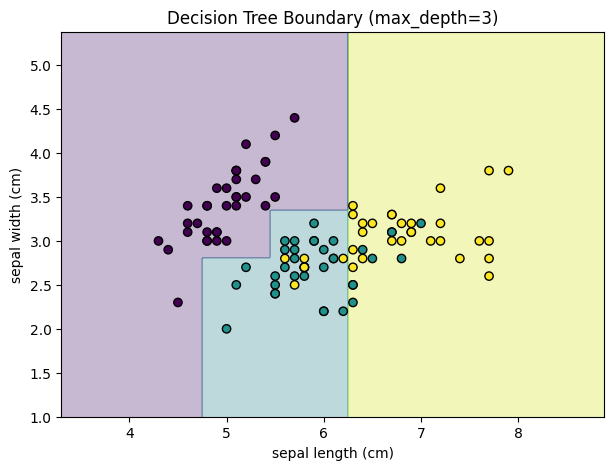

Decision Tree (max_depth=None)
Train Accuracy: 0.943
Test Accuracy : 0.644
Gap           : 0.298
------------------------------


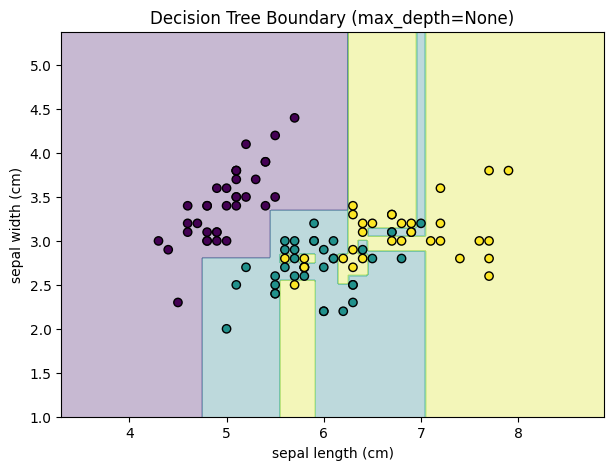

In [24]:
depth_list = [1, 3, None]

for depth in depth_list:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_acc, test_acc, gap = evaluate_model(model, X_train, X_test, y_train, y_test)

    print(f"Decision Tree (max_depth={depth})")
    print(f"Train Accuracy: {train_acc:.3f}")
    print(f"Test Accuracy : {test_acc:.3f}")
    print(f"Gap           : {gap:.3f}")
    print("-" * 30)

    plot_decision_boundary(model, X_train, y_train, f"Decision Tree Boundary (max_depth={depth})")

### Decision Tree 結果解讀

#### 當 max_depth 很小（例如 1）
- 規則很少
- 決策邊界簡單
- 若 train/test accuracy 都偏低，表示模型太簡單
- 這通常代表 **high bias / underfitting**

#### 當 max_depth 適中（例如 3）
- 可以學到更多資料規律
- train/test accuracy 可能較平衡
- 往往是比較合理的模型複雜度

#### 當 max_depth 很大或不限制（例如 None）
- 決策邊界容易變得很碎
- train accuracy 常非常高
- 若 test accuracy 沒有同步提高，甚至下降，表示模型過度記住訓練資料
- 這通常代表 **high variance / overfitting**

## 6. 統整比較表

| 模型 | 參數 | 邊界特徵 | Train Accuracy | Test Accuracy | 傾向 |
|------|------|----------|----------------|---------------|------|
| KNN | k 小 | 鋸齒、貼近局部資料 | 高 | 不一定高 | High Variance / Overfitting |
| KNN | k 大 | 平滑、較大範圍平均 | 下降 | 可能下降 | High Bias / Underfitting |
| Decision Tree | max_depth 小 | 切分少、邊界簡單 | 低 | 低 | High Bias / Underfitting |
| Decision Tree | max_depth 大 | 切分多、邊界複雜 | 高 | 不一定高 | High Variance / Overfitting |

### 觀察結論

從 KNN 與 Decision Tree 的結果可發現，模型複雜度提升時，train accuracy 往往會上升，但 test accuracy 不一定同步提升。若模型在訓練集表現極佳，卻無法在測試集維持相近表現，通常代表模型對訓練資料過度敏感，屬於 high variance / overfitting。相反地，若模型在訓練集與測試集的表現都不理想，則表示模型本身過於簡化，屬於 high bias / underfitting。

因此，在實際建模中，重點並不是讓模型在訓練集上取得最高分，而是找到一個能兼顧訓練表現與測試泛化能力的平衡點。

## 7. 如何用 train/test accuracy 判斷模型狀態

### Overfitting 的常見訊號
- train accuracy 很高
- test accuracy 明顯低於 train accuracy
- train/test gap 較大

### Underfitting 的常見訊號
- train accuracy 不高
- test accuracy 也不高
- 代表模型連訓練資料都學不好

### 比較理想的情況
- train accuracy 不錯
- test accuracy 也接近 train accuracy
- gap 不大

## 8. 一句話總結

- **High Variance**：模型太容易被訓練資料細節影響，常見表現為 train 高、test 落差大
- **High Bias**：模型太簡單，常見表現為 train 和 test 都不高
- 判斷模型好不好，不能只看 train accuracy，而要一起看 test accuracy 與兩者差距